In [1]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import pandas as pd
import numpy as np
from textwrap import fill

plt.style.use("mystyle.mplstyle")

def add_percentage_labels(ax, counts, total):
    label_offset = ax.get_xlim()[1] * 0.015
    for y, value in enumerate(counts.values):
        percentage = value / total * 100
        ax.text(
            value + label_offset,
            y,
            f"{value} ({percentage:.1f}%)",
            va="center",
            color="0.25",
        )

figures_path = "../../literature-review-paper/src/figures/"

In [2]:
columns = [
    "paper_id",
    "publication_year",
    "publication_type",
    "venue_type",
    "research_type",
    "methodological_approach",
    "data_source",
    "assessment_orientation",
    "Environmental impacts",
    "Lifecycle stages",
    "System locus",
    "Management and intervention levers"
]

df = pd.read_csv(
    "../artifacts/merge.csv",
    usecols=columns
)
df.head()

,paper_id,publication_year,publication_type,venue_type,research_type,methodological_approach,data_source,assessment_orientation,Environmental impacts,Lifecycle stages,System locus,Management and intervention levers
0,1,2025,Conference Paper,Other Venues,Philosophical Paper,literature analysis,secondary,ex post,Carbon emissions,Operational,Facility and energy infrastructure;Compute har...,Incentives and policy
1,2,2011,Journal Paper,Parallel and Distributed Venues,Validation Research,modeling;simulations,secondary,ex ante,Carbon emissions,Operational,Facility and energy infrastructure;Software an...,Workload and runtime optimization
2,3,2024,Conference Paper,HPC Venues,Validation Research,data analysis;modeling;simulations,primary,ex post;ex ante,Materials and waste,Production;Operational;End of Life,Facility and energy infrastructure;Compute har...,Measurement and accounting;Workload and runtim...
3,4,2024,Conference Paper,HPC Venues,Experience Paper,data analysis;modeling;experiments on real sys...,primary,ex post,Carbon emissions,Operational,Software and workloads;Compute hardware,Workload and runtime optimization;Incentives a...
4,5,2019,Conference Paper,Parallel and Distributed Venues,Experience Paper,data analysis;modeling,primary;secondary,ex ante,Water use,Production;Operational,Facility and energy infrastructure,Infrastructure design


In [3]:
for col in columns[5:]:
    df[col] = df[col].str.split(";").apply(lambda vals: [v.strip() for v in vals])
df.head()

,paper_id,publication_year,publication_type,venue_type,research_type,methodological_approach,data_source,assessment_orientation,Environmental impacts,Lifecycle stages,System locus,Management and intervention levers
0,1,2025,Conference Paper,Other Venues,Philosophical Paper,[literature analysis],[secondary],[ex post],[Carbon emissions],[Operational],"[Facility and energy infrastructure, Compute h...",[Incentives and policy]
1,2,2011,Journal Paper,Parallel and Distributed Venues,Validation Research,"[modeling, simulations]",[secondary],[ex ante],[Carbon emissions],[Operational],"[Facility and energy infrastructure, Software ...",[Workload and runtime optimization]
2,3,2024,Conference Paper,HPC Venues,Validation Research,"[data analysis, modeling, simulations]",[primary],"[ex post, ex ante]",[Materials and waste],"[Production, Operational, End of l...","[Facility and energy infrastructure, Compute h...","[Measurement and accounting, Workload and runt..."
3,4,2024,Conference Paper,HPC Venues,Experience Paper,"[data analysis, modeling, experiments on real ...",[primary],[ex post],[Carbon emissions],[Operational],"[Software and workloads, Compute hardware]","[Workload and runtime optimization, Incentives..."
4,5,2019,Conference Paper,Parallel and Distributed Venues,Experience Paper,"[data analysis, modeling]","[primary, secondary]",[ex ante],[Water use],"[Production, Operational]",[Facility and energy infrastructure],[Infrastructure design]


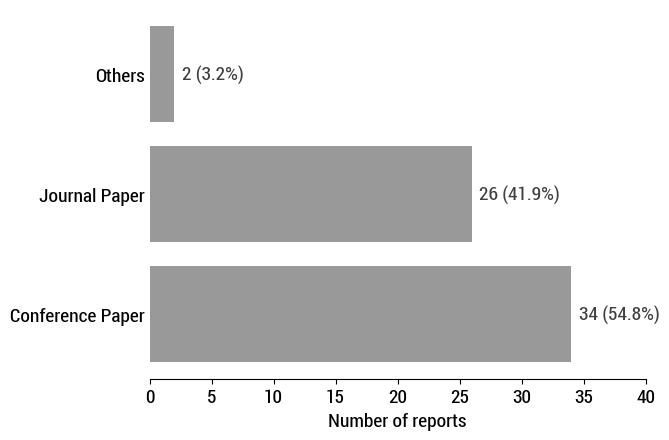

In [4]:
def publication_type_plot(df):
    publication_type_counts = df["publication_type"].value_counts()

    fig, ax = plt.subplots()

    plt.barh(
        publication_type_counts.index,
        publication_type_counts.values,
        color="0.6",
    )
    
    ax.set_ylabel("")
    ax.set_xlabel("Number of reports")

    ax.set_xlim(0, 40)
    
    ax.tick_params(axis="y",length=0)
    
    ax.spines[["right", "left", "top"]].set_visible(False)

    add_percentage_labels(ax, publication_type_counts, len(df))

    # plt.savefig(figures_path + "publication_type.pdf", bbox_inches="tight")
    plt.show()

publication_type_plot(df)

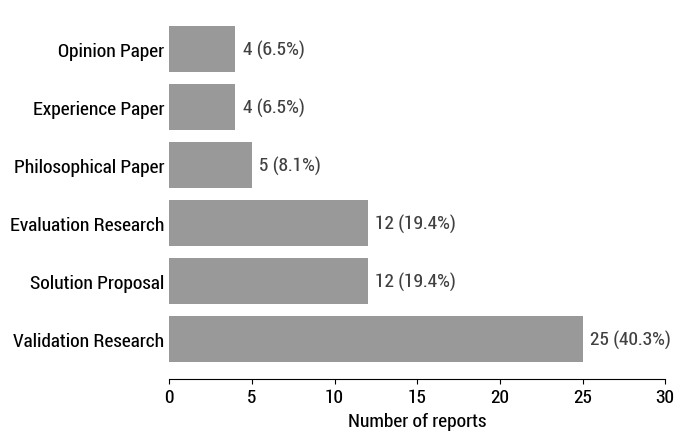

In [5]:
def research_type_plot(df):
    research_type_counts = df["research_type"].value_counts()

    fig, ax = plt.subplots()

    plt.barh(
        research_type_counts.index,
        research_type_counts.values,
        color="0.6",
    )
    
    plt.ylabel("")
    plt.xlabel("Number of reports")

    plt.xlim(0, 30)

    ax.spines[["right", "left", "top"]].set_visible(False)
    
    plt.tick_params(axis="y",length=0)

    add_percentage_labels(ax, research_type_counts, len(df))

    # plt.savefig(figures_path + "research_type.pdf", bbox_inches="tight")
    plt.show()

research_type_plot(df)

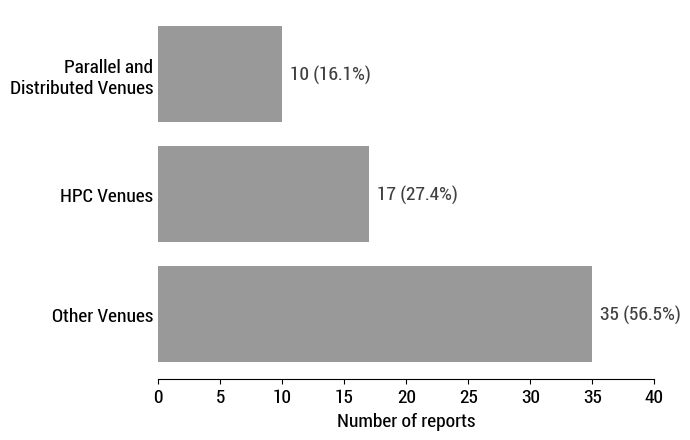

In [6]:
def venue_type_plot(df):
    venue_type_counts = df["venue_type"].value_counts()

    fig, ax = plt.subplots()

    wrapped_index = [fill(s, width=20) for s in venue_type_counts.index]

    ax.barh(
        wrapped_index,
        venue_type_counts.values,
        color="0.6",
    )
    
    ax.set_ylabel("")
    ax.set_xlabel("Number of reports")

    ax.set_xlim(0, 40)

    ax.spines[["right", "left", "top"]].set_visible(False)
    
    ax.tick_params(axis="y",length=0)

    add_percentage_labels(ax, venue_type_counts, len(df))

    # plt.savefig(figures_path + "venue_type.pdf", bbox_inches="tight")
    plt.show()

venue_type_plot(df)

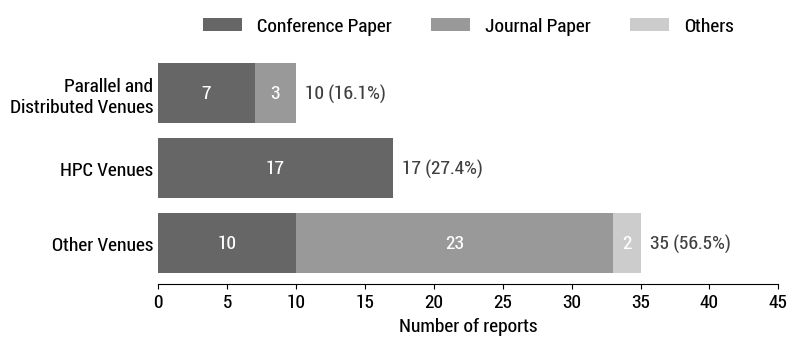

In [7]:
def venue_type_by_publication_plot(df):
    ct = pd.crosstab(df["venue_type"], df["publication_type"])
    ct = ct.loc[df["venue_type"].value_counts().index]
    totals = ct.sum(axis=1)

    grays = ["0.4", "0.6", "0.8"]
    left = [0.0] * len(ct)
    y_positions = np.arange(len(ct))
    wrapped_index = [fill(s, width=20) for s in ct.index]

    fig, ax = plt.subplots(figsize=(8, 3))

    for i, pub_type in enumerate(ct.columns):
        values = ct[pub_type]
        ax.barh(y_positions, values, left=left, color=grays[i], label=pub_type)
        for j, (v, l) in enumerate(zip(values, left)):
            if v > 0:
                ax.text(
                    l + v / 2, j,
                    f"{v}",
                    ha="center", va="center",
                    color="white",
                )
        left = [l + v for l, v in zip(left, values)]

    ax.set_yticks(y_positions)
    ax.set_yticklabels(wrapped_index)

    ax.set_xlim(0, 45)
    add_percentage_labels(ax, totals, len(df))
    ax.set_xlabel("Number of reports")
    ax.set_ylabel("")
    ax.tick_params(axis="y", length=0)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncols=3)

    ax.spines[["right", "left", "top"]].set_visible(False)

    plt.savefig(figures_path + "venue_type_by_publication.pdf", bbox_inches="tight")
    plt.show()

venue_type_by_publication_plot(df)

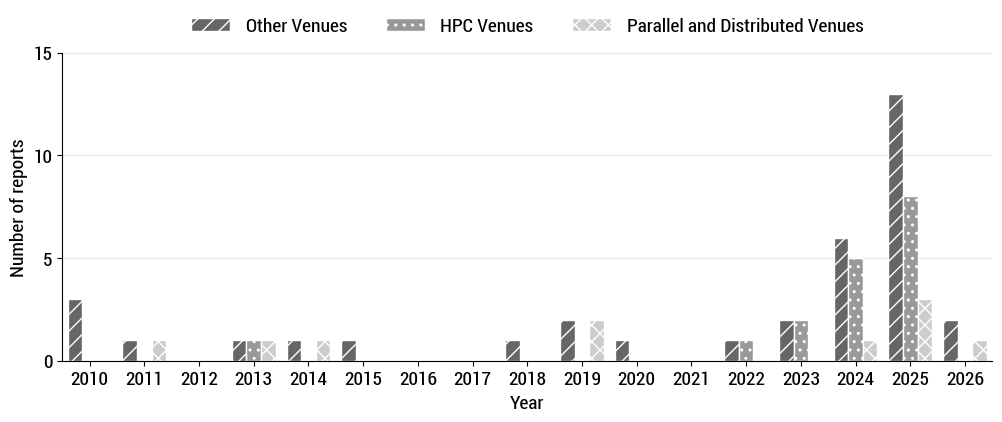

venue_type        Other Venues  HPC Venues  Parallel and Distributed Venues
publication_year                                                           
2010                         3           0                                0
2011                         1           0                                1
2012                         0           0                                0
2013                         1           1                                1
2014                         1           0                                1
2015                         1           0                                0
2016                         0           0                                0
2017                         0           0                                0
2018                         1           0                                0
2019                         2           0                                2
2020                         1           0                                0
2021        

In [8]:
def venue_type_by_year_plot(df):
    venue_order = df["venue_type"].value_counts().index.tolist()
    years = list(range(2010, 2027))

    ct = pd.crosstab(df["publication_year"], df["venue_type"]).reindex(
        index=years, columns=venue_order, fill_value=0
    )

    grays = ["0.4", "0.6", "0.8"]
    hatches = ["//", "..", "xx"]
    width = 0.8 / len(venue_order)
    offsets = [(i - (len(venue_order) - 1) / 2) * width for i in range(len(venue_order))]

    fig, ax = plt.subplots(figsize=(12, 4))

    for venue, color, hatch, offset in zip(venue_order, grays, hatches, offsets):
        ax.bar(
            ct.index + offset,
            ct[venue].values,
            width=width,
            color=color,
            hatch=hatch,
            edgecolor="white",
            label=venue,
        )

    ax.set_xlim(years[0] - 0.5, years[-1] + 0.5)
    ax.set_xticks(years)
    ax.set_xlabel("Year")
    ax.set_yticks([0, 5, 10, 15])
    ax.set_ylabel("Number of reports")
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncols=3)

    ax.spines[["right", "top"]].set_visible(False)

    ax.grid(axis='y', color="0.9", linestyle='-', linewidth=1)

    plt.savefig(figures_path + "venue_type_by_year.pdf", bbox_inches="tight")
    plt.show()

    print(ct)
    print()
    print("Totals by year:")
    print(ct.sum(axis=1))
    print()
    print("Totals by venue:")
    print(ct.sum(axis=0))

venue_type_by_year_plot(df)

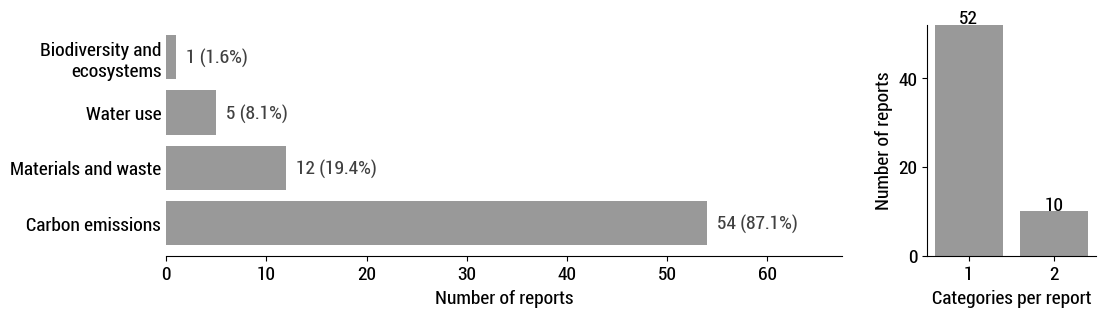

Facet: Environmental impacts

Category counts:
Environmental impacts
Carbon emissions               54
Materials and waste            12
Water use                       5
Biodiversity and ecosystems     1
Name: count, dtype: int64

Breadth distribution (reports covering N categories):
Environmental impacts
1    52
2    10
Name: count, dtype: int64


In [9]:
def category_counts(df, facet_name):
    """Counts of reports per category in a facet, sorted descending."""
    return df[facet_name].explode().value_counts()

def breadth_distribution(df, facet_name):
    """Number of reports covering 1, 2, 3, ... categories of the facet."""
    sizes = df[facet_name].apply(len)
    return sizes.value_counts().reindex(range(1, sizes.max() + 1), fill_value=0).sort_index()

def show_facet(df, facet_name):
    counts = category_counts(df, facet_name)
    breadth = breadth_distribution(df, facet_name)

    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12, 3), gridspec_kw={"width_ratios": [4, 1]})

    wrapped_index = [fill(s, width=20) for s in counts.index]
    ax_left.barh(wrapped_index, counts.values, color="0.6")
    ax_left.set_xlabel("Number of reports")
    ax_left.set_xlim(0, counts.values.max() * 1.25)
    ax_left.tick_params(axis="y", length=0)
    ax_left.spines[["right", "left", "top"]].set_visible(False)
    label_offset = ax_left.get_xlim()[1] * 0.015
    for y, value in enumerate(counts.values):
        ax_left.text(
            value + label_offset, y,
            f"{value} ({value / len(df) * 100:.1f}%)",
            va="center", color="0.25",
        )

    ax_right.bar(breadth.index, breadth.values, color="0.6")
    ax_right.set_xlabel("Categories per report")
    ax_right.set_ylabel("Number of reports")
    ax_right.set_xticks(list(breadth.index))
    ax_right.set_ylim(0, breadth.values.max())
    ax_right.spines[["right", "top"]].set_visible(False)
    for x, v in zip(breadth.index, breadth.values):
        ax_right.text(x, v + 0.3, str(int(v)), ha="center")

    plt.savefig(figures_path + "env-impacts.pdf", bbox_inches="tight")
    plt.show()

    print(f"Facet: {facet_name}")
    print()
    print("Category counts:")
    print(counts)
    print()
    print("Breadth distribution (reports covering N categories):")
    print(breadth)

show_facet(df, "Environmental impacts")

In [ ]:
def env_impacts_by_year_plot(df):
    env_order = [
        "Carbon emissions",
        "Materials and waste",
        "Water use",
        "Biodiversity and ecosystems",
    ]
    years = list(range(2010, 2027))

    ct = (
        df[["publication_year", "Environmental impacts"]]
        .explode("Environmental impacts")
        .groupby(["publication_year", "Environmental impacts"])
        .size()
        .unstack(fill_value=0)
        .reindex(index=years, columns=env_order, fill_value=0)
    )

    grays = ["0.35", "0.55", "0.75", "0.9"]
    hatches = ["", "//", "..", "xx"]

    fig, ax = plt.subplots(figsize=(12, 4))

    bottom = np.zeros(len(ct))
    for impact, color, hatch in zip(env_order, grays, hatches):
        values = ct[impact].values
        ax.bar(
            ct.index,
            values,
            bottom=bottom,
            color=color,
            hatch=hatch,
            edgecolor="0.3",
            linewidth=0.8,
            label=impact,
        )
        bottom = bottom + values

    ymax = int(np.ceil(bottom.max() / 5) * 5)

    ax.set_xlim(years[0] - 0.5, years[-1] + 0.5)
    ax.set_xticks(years)
    ax.set_xlabel("Year")
    ax.set_ylim(0, ymax)
    ax.set_yticks(list(range(0, ymax + 1, 5)))
    ax.set_ylabel("Number of reports")
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncols=2)

    ax.spines[["right", "top"]].set_visible(False)
    ax.grid(axis="y", color="0.9", linestyle="-", linewidth=1)

    plt.savefig(figures_path + "env-impacts-by-year.pdf", bbox_inches="tight")
    plt.show()

    print(ct)
    print()
    print("Totals by year:")
    print(ct.sum(axis=1))
    print()
    print("Totals by impact:")
    print(ct.sum(axis=0))

env_impacts_by_year_plot(df)

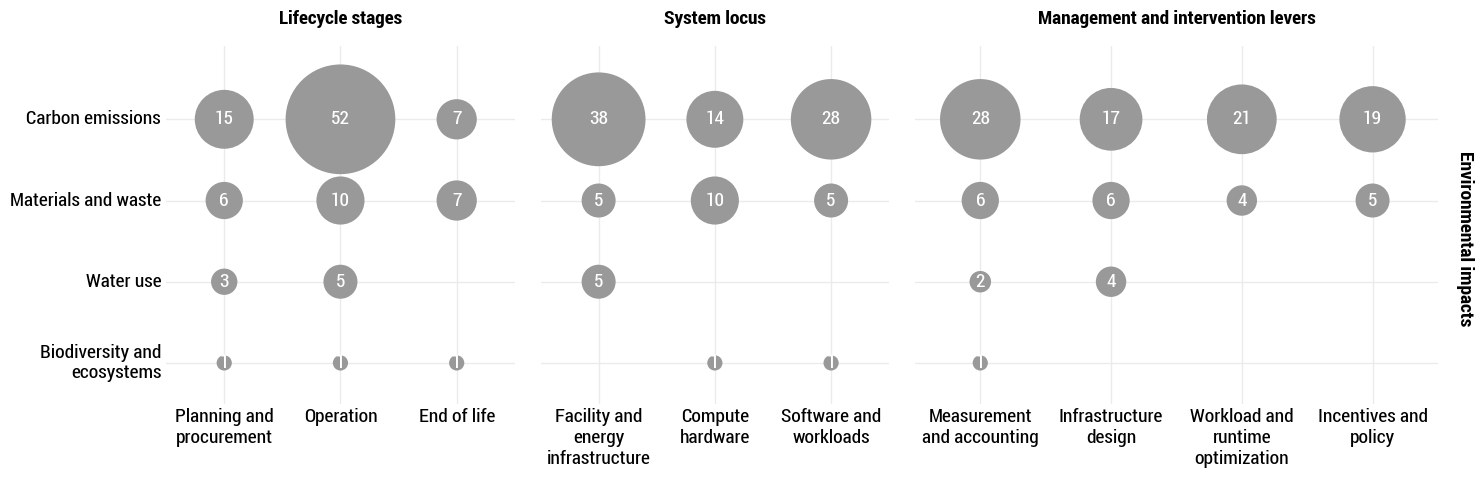

Environmental impacts x Lifecycle stages:
Lifecycle stages             Production  Operational  End of Life
Environmental impacts                                                        
Carbon emissions                                   15         52            7
Materials and waste                                 6         10            7
Water use                                           3          5            0
Biodiversity and ecosystems                         1          1            1

Environmental impacts x System locus:
System locus                 Facility and energy infrastructure  \
Environmental impacts                                             
Carbon emissions                                             38   
Materials and waste                                           5   
Water use                                                     5   
Biodiversity and ecosystems                                   0   

System locus                 Compute hardware  Software and 

In [10]:
def facet_pair_bubbles_plot(df):
    row_facet = "Environmental impacts"
    col_facets = ["Lifecycle stages", "System locus", "Management and intervention levers"]
    facet_orders = {
        row_facet: ["Carbon emissions", "Materials and waste", "Water use", "Biodiversity and ecosystems"],
        "Lifecycle stages": ["Production", "Operational", "End of Life"],
        "System locus": ["Facility and energy infrastructure", "Compute hardware", "Software and workloads"],
        "Management and intervention levers": [
            "Measurement and accounting",
            "Infrastructure design",
            "Workload and runtime optimization",
            "Incentives and policy",
        ],
    }
    title_font = FontProperties(family="Roboto Condensed", weight="bold", size=14)

    def pair_counts(col_facet):
        exploded = (
            df[[row_facet, col_facet]]
            .explode(row_facet)
            .explode(col_facet)
            .dropna()
        )
        return (
            exploded.groupby([row_facet, col_facet])
            .size()
            .unstack(fill_value=0)
        )

    env_order = facet_orders[row_facet]
    cts = [
        pair_counts(cf).reindex(
            index=env_order,
            columns=facet_orders[cf],
            fill_value=0,
        )
        for cf in col_facets
    ]

    n_env = len(env_order)

    fig, axes = plt.subplots(
        1, 3,
        sharey=True,
        gridspec_kw={"width_ratios": [2, 2, 3]},
        figsize=(15, 5),
    )

    SIZE_K = 120

    for ax, ct, title in zip(axes, cts, col_facets):
        n_col = ct.shape[1]
        for yi, env_cat in enumerate(ct.index):
            for xi, col_cat in enumerate(ct.columns):
                count = ct.iat[yi, xi]
                if count > 0:
                    ax.scatter(xi, yi, s=count * SIZE_K, color="0.6", edgecolors="none")
                    ax.text(xi, yi, str(count), ha="center", va="center", color="white")

        ax.set_xticks(range(n_col))
        ax.set_xticklabels([fill(c, width=14) for c in ct.columns])
        ax.set_xlim(-0.5, n_col - 0.5)

        ax.set_xticks(np.arange(n_col + 1) - 0.5, minor=True)
        ax.set_yticks(np.arange(n_env + 1) - 0.5, minor=True)
        ax.grid(which="major", color="0.92", linewidth=1)

        ax.tick_params(length=0)
        ax.tick_params(which="minor", length=0)
        for s in ax.spines.values():
            s.set_visible(False)
        ax.set_title(title, fontproperties=title_font, pad=16)

    axes[0].set_yticks(range(n_env))
    axes[0].set_yticklabels(
        [fill(c, width=20) for c in env_order],
        va="center",
        multialignment="right",
    )
    axes[0].set_ylim(n_env - 0.5, -0.9)

    fig.text(0.99, 0.5, row_facet, rotation=-90, va="center", ha="right", fontproperties=title_font)
    plt.tight_layout(rect=[0, 0, 0.98, 1])

    plt.savefig(figures_path + "facet_pair_bubbles.pdf", bbox_inches="tight")
    plt.show()

    for col_facet, ct in zip(col_facets, cts):
        print(f"{row_facet} x {col_facet}:")
        print(ct)
        print()

facet_pair_bubbles_plot(df)